In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import GroupedLayerControl
from fsspec.utils import infer_compression
import ckanapi as ck

#### Loading in the Data
Using Pandas to open up the Excel file and do some data cleanup line aggregating sex and recalculating the rates since it used a lot of symbols that are not numbers. Then making a separate dataframe that's for statewide data as opposed to county data. Once we find a disease we want to study in further detail, we can use the county data to see if any county is contributing a lot to the increase/decrease in infection over time.
Also rate is calculated as:
$$ \frac{Cases}{Population} * 100,000 $$

The `find_largest_del` function takes in the county dataset and subsets it to the statewide dataset within the function because I'm bad at coding and too lazy to fix it because it works. It also takes in an argument `value_diff` for the thing you want the average of over the years, which means it either takes `'Rate'` or `'Cases'`. It then spits out a dictionary ordered by value so the user can see which diseases have the greatest average rate of change of rate or cases (which are connected so having both of them here is a little redundant but I think it's useful for intuition to have both of them here). I called the function twice and put the outputs into a dataframe to look at them side by side. A little counterintuitive but the negative numbers actually represent an increase from the previous year since if $year_{previous} < year_{current}$ then $sign(year_{previous} - year_{current}) = -1$

From this we can see that Coccidioidomycosis prevalence is increasing the most and Zika Virus prevalence dropping the most. Also that anthrax and whatever "Plague, human" is are both at a steady zero which is good I guess.

In [38]:
infection_df = pd.read_csv('./data/diseases.csv')
infection_df = infection_df[infection_df['Sex'] == 'Total']
infection_df = infection_df.assign(Rate = lambda x: np.round(((x['Cases']/x['Population'])*100_000), decimals = 3))
state_infection_df = infection_df[infection_df['County'] == 'California']

def find_largest_del(df, value_diff):
    '''
    Calculates the average difference between year-1 and year sequentially and averages them over all years for all diseases and places them in a value ordered dictionary

    Parameters:
        df: A pandas dataframe of infectious disease data with a rate column of numeric data and a sex column of total infections
        value_diff: A string that can take the value 'Cases' or 'Rate' and will do the calculation for the selected variable, if neither throws an error

    Returns:
        A value sorted dictionary with disease names as keys and average difference values as values
    '''
    if (value_diff == 'Cases') or (value_diff == 'Rate'):
        pass
    else:
        raise ValueError('value_diff must be either "Cases" or "Rate"')

    diseases = df['Disease'].drop_duplicates().reset_index(drop=True)
    statewide = df[df['County'] == 'California'].replace(to_replace='-', value=0)
    avg_del_infections = [0] * len(diseases)
    for j in range(len(diseases)):
        disease = diseases[j]
        tmp = statewide[statewide['Disease'] == disease]
        lbound = min(tmp['Year'])+1
        ubound = max(tmp['Year'])+1
        del_infections = [0] * len(range(lbound,ubound))

        for i in range(lbound,ubound):
            tmp_yr_minone = tmp[tmp['Year'] == i-1]
            tmp_yr = tmp[tmp['Year'] == i]
            diff = float(tmp_yr_minone[value_diff].iloc[0]) - float(tmp_yr[value_diff].iloc[0])
            del_infections[i-lbound] = diff
        avg_del_infections[j] = np.mean(del_infections)

    del_cases_dict = {diseases[i]:avg_del_infections[i] for i in range(len(diseases))}
    sorted_del_cases_dict = sorted(del_cases_dict.items(), key=lambda x:x[1])
    sorted_del_cases_dict = dict(sorted_del_cases_dict)
    return sorted_del_cases_dict


#input either 'Cases' or 'Rate' as value_diff
rates = find_largest_del(infection_df,value_diff='Rate')
cases = find_largest_del(infection_df,value_diff='Cases')
disease_comparison = pd.DataFrame([cases,rates]).transpose().rename(columns={0:'Cases',1:'Rate'})
disease_comparison

,Cases,Rate
Coccidioidomycosis,-343.772727,-0.859136
Campylobacteriosis,-291.000000,-0.661545
Salmonellosis,-130.590909,-0.272409
Shiga toxin-producing E. coli (STEC) without HUS,-111.181818,-0.281545
Shigellosis,-104.545455,-0.234864
Cryptosporidiosis,-35.090909,-0.086409
Yersiniosis,-34.681818,-0.087727
Legionellosis,-29.500000,-0.074818
Cyclosporiasis,-12.333333,-0.031667
Vibrio Infection (non-Cholera),-10.727273,-0.026364


#### Visualizing Infections over Time
This code block defines the diseases with the fastest growing incidence and the fastest declining incidence, mostly decided by looking at the comparison dataframe and choosing the ones that looked like they had the biggest average change not gonna lie. There's also a little function for preparing the data for visualization and then outputting a line graph.

The png files are accessible in the Figures folder.

In [239]:
top_increasing = list(disease_comparison.index[0:8])
top_decreasing = list(disease_comparison.index[47:52])
def visualize_tops(state_df, lst, lineplotted, loc, giardia = False):
    '''
    Visualizes the number of cases of the diseases with the most increasing or decreasing incidence with a line plot

    Parameters:
        state_df: A pandas dataframe containing statewide infection data
        lst: A list of the diseases with the most increasing or decreasing infections (or just a list of infections i guess
        lineplotted: A string that can take the value 'Cases' or 'Rate' and will line plot that statistic (but since one is just a transformation of the other they look the same)
        giardia: A boolean stating whether or not to include giardia in the final plot, I found that giardia highly skewed the original plot so I added this option
        loc: A string for the file path you want to save the figure to

    Returns:
        A seaborn lineplot
    '''
    if giardia == True or lst == top_increasing:
        pass
    else:
        lst.remove('Giardiasis')
    df = {lst[i]:list(state_df[state_df['Disease'] == lst[i]][lineplotted]) for i in range(len(lst))}
    df = pd.DataFrame.from_dict(df, orient='index')
    df = df.transpose()
    df.index = state_df['Year'].unique()
    if lst == top_decreasing:
        df[['Chikungunya Virus Infection', 'Zika Virus Infection']] = df[['Chikungunya Virus Infection', 'Zika Virus Infection']].shift(15)
    else:
        pass
    sns.set_theme(rc={'figure.figsize':(12,9)})
    plt = sns.lineplot(df)
    plt.get_figure().savefig(loc)
    return plt

<Axes: >

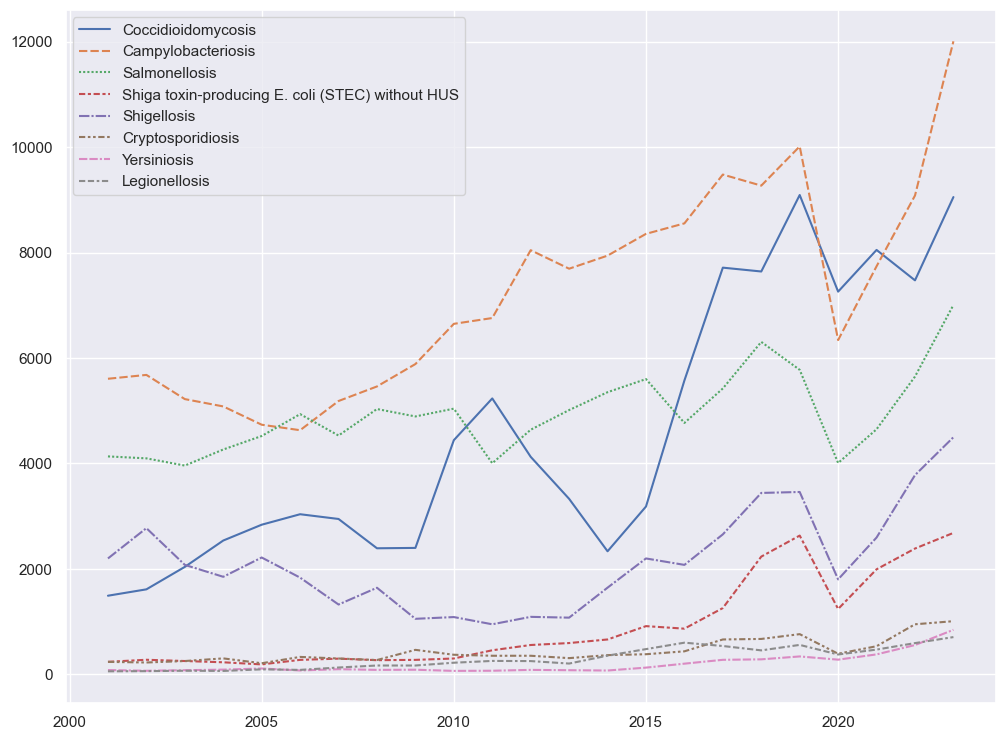

In [240]:
visualize_tops(state_infection_df, top_increasing, 'Cases', './Figures/most_increasing_diseases.png')

<Axes: >

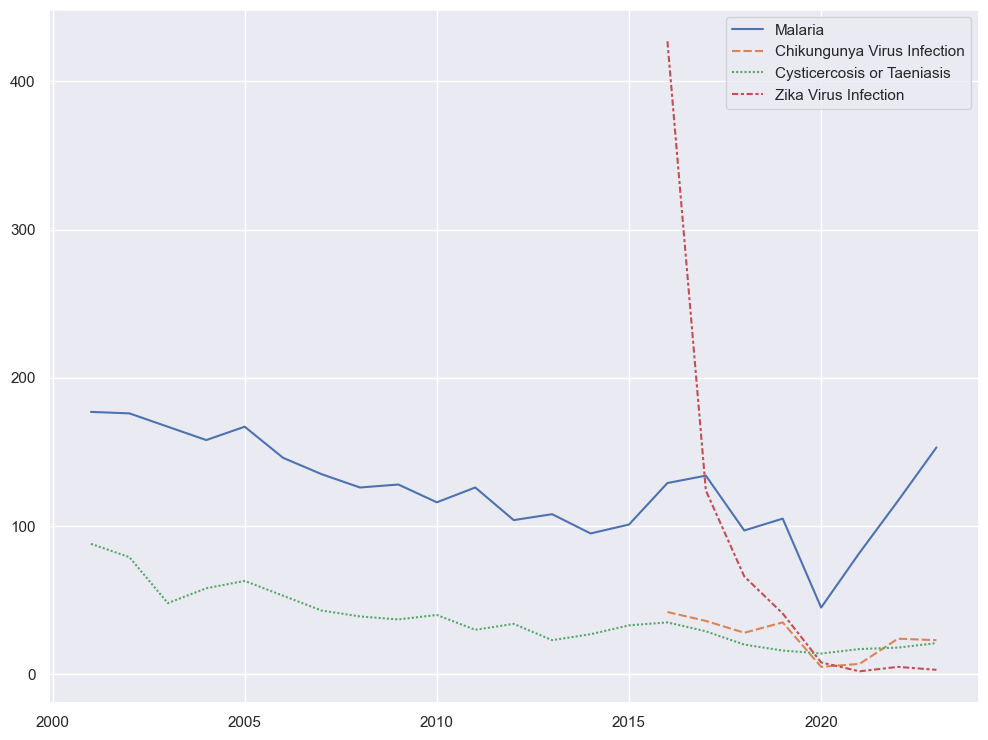

In [241]:
visualize_tops(state_infection_df, top_decreasing, 'Cases', './Figures/most_decreasing_diseases.png')

<Axes: >

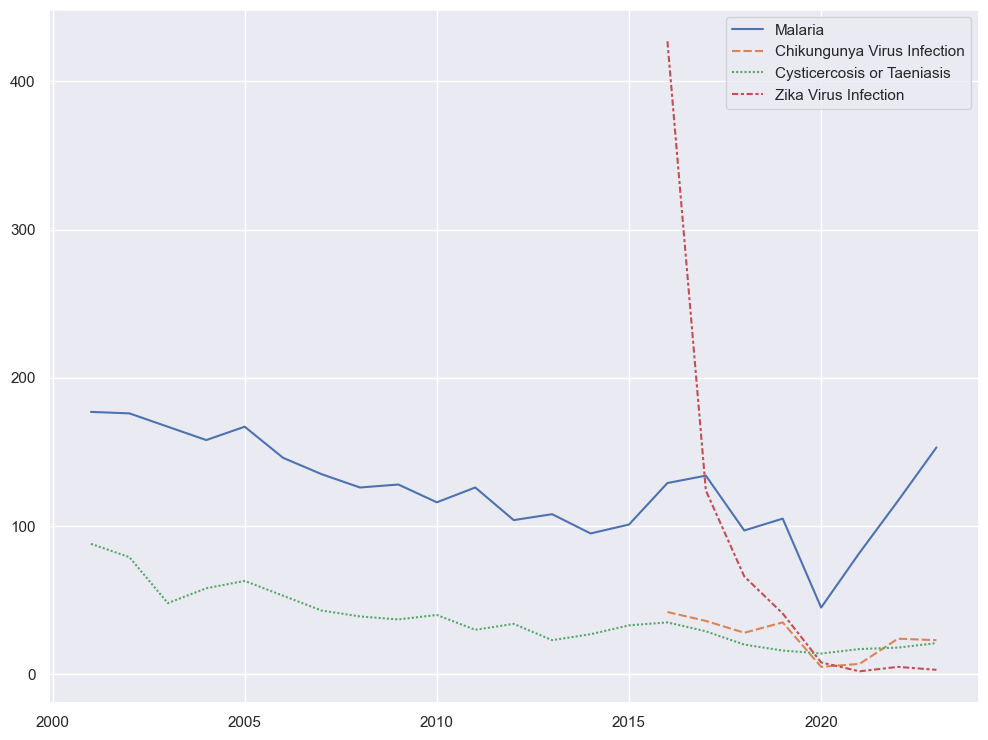

In [242]:
visualize_tops(state_infection_df, top_decreasing, 'Cases', './Figures/most_decreasing_diseases_giardia.png', giardia = True)

#### Valley Fever!!
Ok so it looks like we're doing valley fever for our project so this will be some exploratory analysis on valley fever itself

First Cell just loads in the data, second one is just to load in the map to be visible in juptyer notebook.

In [104]:
county_data='https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/california-counties.geojson'
vfever_data_county = infection_df[infection_df['Disease'] == 'Coccidioidomycosis']
vfever_data_county = vfever_data_county.drop(vfever_data_county[vfever_data_county['County'] == 'California'].index).reset_index()

In [122]:
from IPython.display import display
import branca.colormap as cmp
import folium.plugins
def show_map(m, w = 800, h = 500):
    fig = folium.Figure(width = w, height = h)
    fig.add_child(m)
    display(m)
colors = cmp.LinearColormap(['#ffffcc','#a1dab4','#41b6c4','#225ea8'], vmin=0, vmax=max(vfever_data_county['Cases']))

#### Maps!

First cell is a map of the valley fever cases for 2013 and 2023, I can add more years but this is to visualize how the number of cases has increased over the years.

Second cell is a map of the difference in cases between 2013 and 2023, might be a little redundant so if we choose not to use it I can remove it from the codebase.

Both maps show a pattern with dustier areas.

In [125]:
prev_vfever = vfever_data_county[vfever_data_county['Year'] == 2013].reset_index()
new_vfever = vfever_data_county[vfever_data_county['Year'] == 2023].reset_index()
prev_vfever_colors = {prev_vfever.loc[i,'County']: colors(prev_vfever.loc[i,'Cases'])
                     for i in range(len(prev_vfever))}
new_vfever_colors = {new_vfever.loc[i,'County']: colors(new_vfever.loc[i,'Cases'])
                     for i in range(len(new_vfever))}


m = folium.Map(location = [37,-120], zoom_start = 6, tiles="cartodbpositron", overlay = False)
prev_map_group = folium.FeatureGroup(name = '2013 Cases', overlay = False)
current_map_group = folium.FeatureGroup(name = '2023 Cases', overlay = False)

folium.GeoJson(
        county_data,
        style_function=lambda feature: {
            "fillColor": prev_vfever_colors[feature['properties']['name']],
            "color": "black",
            "weight": 1,
            "dashArray": "1",
            "fillOpacity": .8,
        }
    ).add_to(prev_map_group)

folium.GeoJson(
        county_data,
        style_function=lambda feature: {
            "fillColor": new_vfever_colors[feature['properties']['name']],
            "color": "black",
            "weight": 1,
            "dashArray": "1",
            "fillOpacity": .8,
        }
    ).add_to(current_map_group)

prev_map_group.add_to(m)
current_map_group.add_to(m)
colors.caption = 'Coccidioidomycosis Cases Scale'
colors.add_to(m)
folium.plugins.GroupedLayerControl(groups = {'Yearly Coccidioidomycosis':[prev_map_group, current_map_group]},collapsed=False).add_to(m)

show_map(m)

In [126]:
diff_vfever = new_vfever['Cases'] - prev_vfever['Cases']
diff_vfever = diff_vfever.to_frame().assign(County = new_vfever['County'])
diff_colors = diff_colors = cmp.LinearColormap(['#ffffd4','#fed98e','#fe9929','#cc4c02'], vmin=0, vmax=max(diff_vfever['Cases']))
diff_vfever_colors = {diff_vfever.loc[i,'County']: diff_colors(diff_vfever.loc[i,'Cases'])
                     for i in range(len(diff_vfever))}
n = folium.Map(location = [37,-120], zoom_start = 6, tiles="cartodbpositron", overlay = False)
diff_map_group = folium.FeatureGroup(name = '2013 Cases - 2023 Cases', overlay = True)
folium.GeoJson(
        county_data,
        style_function=lambda feature: {
            "fillColor": diff_vfever_colors[feature['properties']['name']],
            "color": "black",
            "weight": 1,
            "dashArray": "1",
            "fillOpacity": .8,
        }
    ).add_to(diff_map_group)
folium.LayerControl(collapsed=False, ).add_to(m)
diff_map_group.add_to(n)
diff_colors.caption = '2013 and 2023 Difference in Coccidioidomycosis Cases Scale'
diff_colors.add_to(n)
show_map(n)

#### Possible useful article and more visualizations and new dataset

More exploratory analysis on purely Valley Fever data, no other predictors yet
Using this dataset: https://www.cdph.ca.gov/Programs/CID/DCDC/Pages/ValleyFeverProvisionalDashboard.aspx

https://wwwnc.cdc.gov/eid/article/31/5/24-1338_article
maybe useful article ^




In [193]:
age_vfever = pd.read_excel('./Data/ValleyFeverDashboard_Data.xlsx', sheet_name = 'Cases_Rates by Age Group').drop([0])
age_vfever.columns = ['AgeGroup','YearOnset','Cases','Rate']
monthly_vfever = pd.read_excel('./Data/ValleyFeverDashboard_Data.xlsx', sheet_name = 'Cases by Month').drop([0])
monthly_vfever.columns = ['Month', 'Year', 'Cases']
eth_vfever = pd.read_excel('./Data/ValleyFeverDashboard_Data.xlsx', sheet_name = 'Case % by Race_Ethnicity').drop([0])
eth_vfever.columns = ['Race/Ethnicity', 'California_Pop_Percent', 'Case_Percent']

monthly_vfever

,Month,Year,Cases
1,1,2001,78
2,1,2002,139
3,1,2003,112
4,1,2004,251
5,1,2005,189
...,...,...,...
284,12,2020,655
285,12,2021,654
286,12,2022,605
287,12,2023,1445


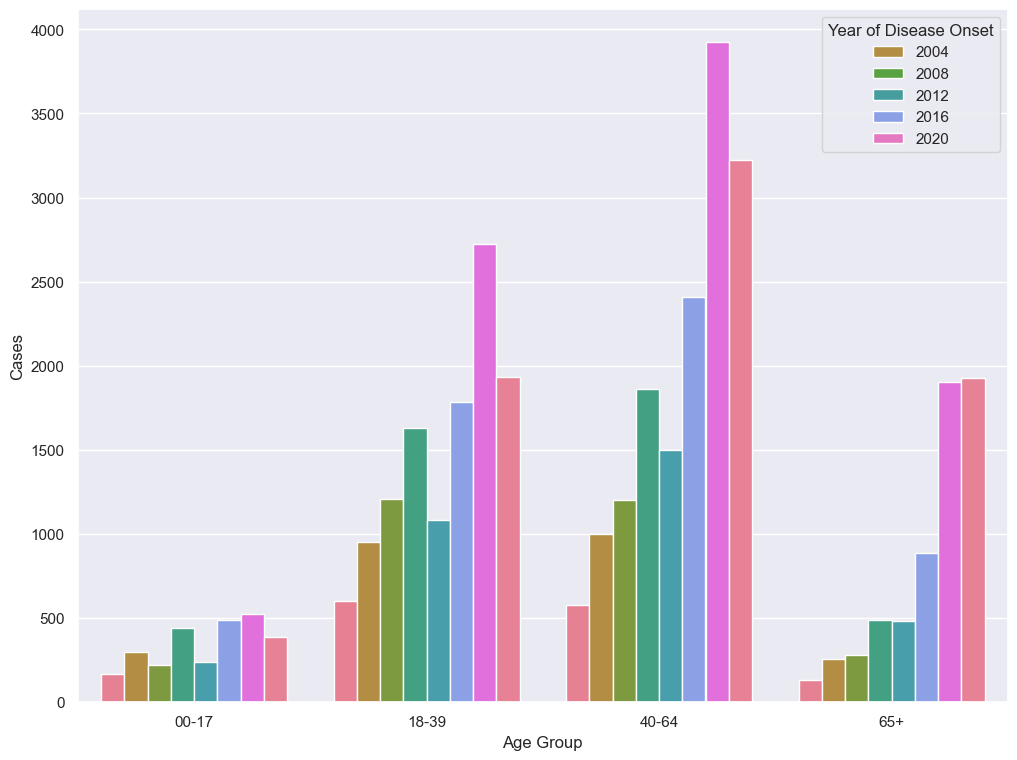

In [235]:
facet_age_vfever = age_vfever.loc[(age_vfever['YearOnset']%3 == 0)]
palette = sns.color_palette("husl", as_cmap=True,n_colors=8)

sns.set_style('darkgrid')
p = sns.barplot(facet_age_vfever, x='AgeGroup', y='Cases', hue='YearOnset', palette=palette)
p.legend(title='Year of Disease Onset')
p.set_xlabel('Age Group')
p.get_figure().savefig('./Figures/CasesByAgebyYear')

C:\Users\Zachary\AppData\Local\Temp\ipykernel_8724\2633285439.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  plt = sns.lineplot(state_infection_df[state_infection_df['County'] == 'California'], x='Year', y='Cases', palette=palette)


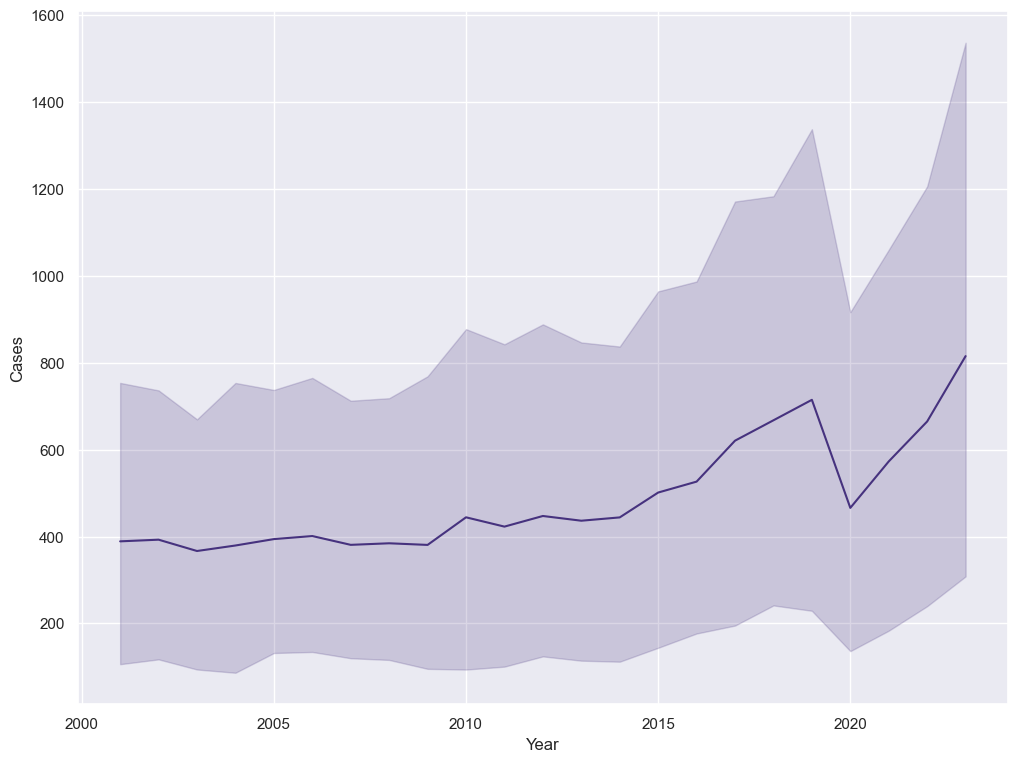

In [232]:
plt = sns.lineplot(state_infection_df[state_infection_df['County'] == 'California'], x='Year', y='Cases', palette=palette)
plt.get_figure().savefig('./Figures/CasesByYear')

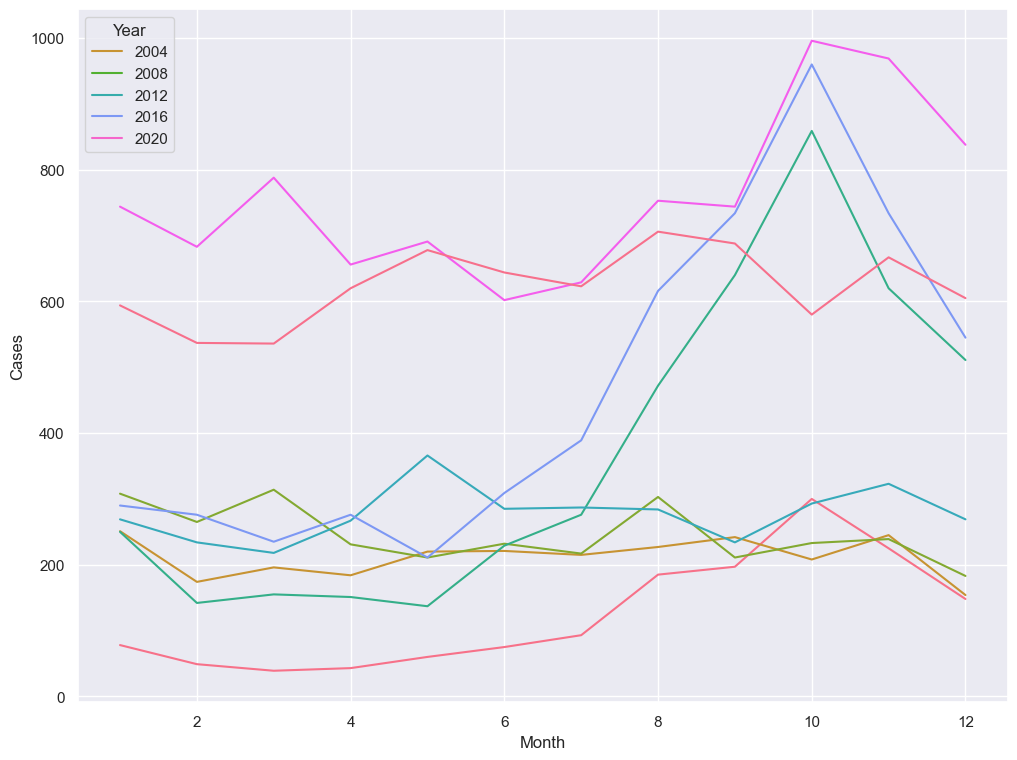

In [234]:
palette = sns.color_palette("husl", as_cmap=True,n_colors=24)
plt = sns.lineplot(monthly_vfever.loc[(monthly_vfever['Year']%3 == 0)], x='Month', y='Cases', hue='Year', palette=palette)
plt.get_figure().savefig('./Figures/CasesByMonthByYear')

#### Weather Data API Calls and Other Stuff

This will include the API stuff for the weather data along with the statistical tests (chi square tests of independence) for age
Maybe include occupation too depending on time and motivation

I couldnt figure out how to work the other weather APIs on the doc but I think I can do this one so Im gonna try this one: https://cimis.water.ca.gov/WSNReportCriteria.aspx#

Also for agricultural stuff I have no idea how to read or use that data so Im gonna go with occupational data for now: https://data.ca.gov/dataset/current-employment-statistics-ces-2